In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


# Turbulence & Transport — Synthetic Reynolds Stress and Particle Flux

This notebook demonstrates Section 9 using controlled synthetic signals. It is **not** a reconstruction of original IR-T1 measurements.

Workflow: fluctuations → E×B velocity → Reynolds stress / particle flux → controlled parameter scans.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import matplotlib.pyplot as plt
from turbulence_transport import (
    generate_synthetic_fluctuations, exb_velocity, reynolds_stress,
    turbulent_particle_flux, parameter_scan
)

In [3]:
data = generate_synthetic_fluctuations()
t = data['time_s']
n = data['density_m3']
phi = data['potential_V']
print('Synthetic samples:', t.size)
print('Sampling frequency (Hz):', data['sampling_frequency_hz'])

Synthetic samples: 4000
Sampling frequency (Hz): 200000.0


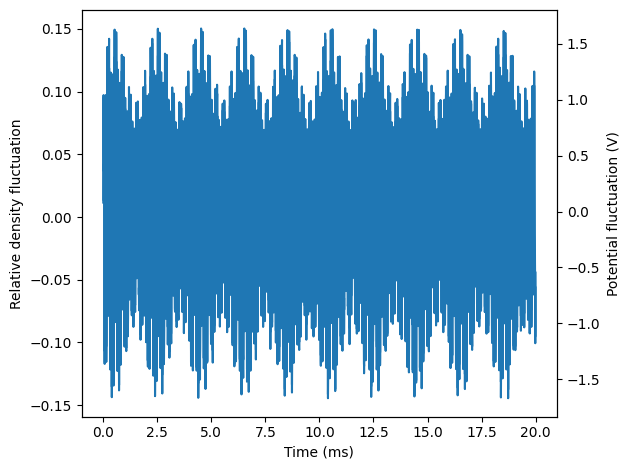

In [4]:
fig, ax1 = plt.subplots()
ax1.plot(t * 1e3, (n - np.mean(n)) / np.mean(n))
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Relative density fluctuation')
ax2 = ax1.twinx()
ax2.plot(t * 1e3, phi - np.mean(phi))
ax2.set_ylabel('Potential fluctuation (V)')
fig.tight_layout()
plt.show()

In [5]:
# Local Cartesian demonstration: B is along z; E has radial (x) and poloidal (y) components.
# The E×B velocity is v_E = E×B/|B|², not the total plasma velocity.
B0 = 0.5
dn = n - np.mean(n)
dphi = phi - np.mean(phi)
Er = -40.0 * dphi
Etheta = 1.0e-15 * dn
E = np.vstack([Er, Etheta, np.zeros_like(Er)])
B = np.vstack([np.zeros_like(t), np.zeros_like(t), np.full_like(t, B0)])
v = exb_velocity(E, B)
vr = v[0] - np.mean(v[0])
vtheta = v[1] - np.mean(v[1])
rs = reynolds_stress(vr, vtheta)
flux = turbulent_particle_flux(n, vr)
print(f'Reynolds stress <v_r~ v_theta~> = {rs:.6g} m^2/s^2')
print(f'Turbulent particle flux <n~ v_r~> = {flux:.6g} m^-2 s^-1')

Reynolds stress <v_r~ v_theta~> = 7407.21 m^2/s^2
Turbulent particle flux <n~ v_r~> = 7.60235e+18 m^-2 s^-1


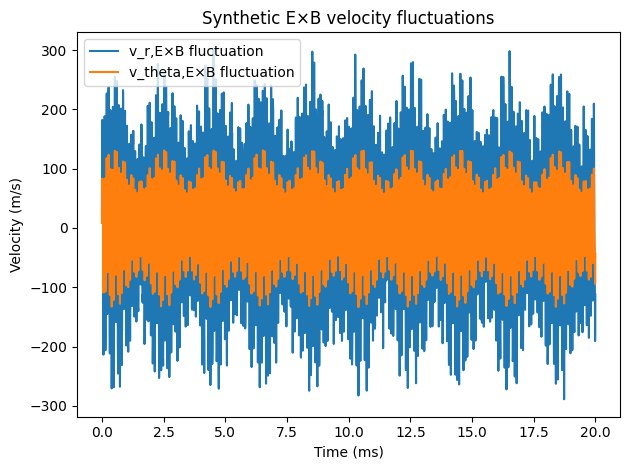

In [6]:
fig, ax = plt.subplots()
ax.plot(t * 1e3, vr, label='v_r,E×B fluctuation')
ax.plot(t * 1e3, vtheta, label='v_theta,E×B fluctuation')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Velocity (m/s)')
ax.legend()
ax.set_title('Synthetic E×B velocity fluctuations')
fig.tight_layout()
plt.show()

In [7]:
# Controlled synthetic parameter scans. These are illustrative sensitivity models, not IR-T1 fits.
scans = {
    'Hydrogen pressure (Torr)': np.array([1.9, 2.3, 2.7]),
    'Limiter position (mm)': np.array([0.0, 5.0, 10.0]),
    'Limiter bias (V)': np.array([-200.0, 0.0, 200.0]),
}
for name, values in scans.items():
    result = parameter_scan(values, name, baseline_response=1.0, sensitivity=0.2, reference_value=values[0])
    print(name, '→', np.round(result['response'], 4))

Hydrogen pressure (Torr) → [1.     1.0421 1.0842]
Limiter position (mm) → [1.00000000e+00 4.50359963e+15 9.00719925e+15]
Limiter bias (V) → [1.  1.2 1.4]
